In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')  # consistent styling for every plot below, seaborn or plain matplotlib

In [2]:
secom = pd.read_csv('ds-sprint-july/projects/projects2_secom/uci-secom.csv')

In [3]:
secom.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [4]:
secom.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


## Setup: selected sensor features

We're working with 5 of the 591 sensor columns instead of all of them, for two reasons:
- **Readability** — tables/plots for 591 features are not something you can actually read or reason about by eye.
- **Clean computation** — `skew`, `kurtosis`, and `shapiro` don't tolerate `NaN`s gracefully, so picking columns with **zero missing values** avoids having to decide on an imputation/dropna strategy before we've even started the stats practice.

Columns picked for a spread of shapes (checked via `.skew()` beforehand):
- `393` — near-symmetric (|skew| ~ 0.1)
- `390` — strong positive skew / heavy right tail
- `570` — negative skew
- `255` — moderate positive skew
- `86` — moderate positive skew, small scale

Swap `SELECTED_FEATURES` for other column indices any time — everything below is written to work off that list.

In [5]:
SELECTED_FEATURES = ['393', '390', '570', '255', '86']
LABEL_COL = 'Pass/Fail'

# Pass/Fail is coded -1 = pass, 1 = fail in the raw data
secom[SELECTED_FEATURES] = secom[SELECTED_FEATURES].astype(float)
secom[SELECTED_FEATURES + [LABEL_COL]].isna().sum()

393          0
390          0
570          0
255          0
86           0
Pass/Fail    0
dtype: int64

## 1. Probability

**Concept.** Probability here is the *frequentist/empirical* estimate: P(event) = (rows where the event is true) / (total rows). We're treating the 1567 SECOM records as a sample from the underlying manufacturing process, so these are estimates of the true pass/fail rate, not the true rate itself.

### 1a. Marginal probabilities from the label distribution

"Marginal" means we're looking at one variable (`Pass/Fail`) in isolation, ignoring every sensor reading. This gives you the baseline failure rate — the number every conditional probability in 1b gets compared against.

**What to observe:** how imbalanced the classes are. A large P(pass) vs. P(fail) gap is normal for manufacturing defect data (most units pass) and has implications later (Week 3) for how you'd evaluate a classifier — but that's out of scope here, just note the imbalance.

**Code walkthrough** (`secom[LABEL_COL].value_counts()`):
- `value_counts()` returns a `Series` indexed by the distinct values found in the column, i.e. an index of `[-1, 1]` mapped to how many times each occurs.
- `label_counts.get(1, 0)` — `.get(key, default)` is dict-style lookup: "give me the count where the index is `1`, or `0` if that value isn't present at all." The `default=0` guards against a `KeyError` if, say, a filtered subset happened to contain no failures.
- The values `1` and `-1` aren't something we chose — they're how this dataset encodes the label: **`1` = fail, `-1` = pass**. Always check a dataset's own encoding before assuming 1/0 or True/False.

In [6]:
label_counts = secom[LABEL_COL].value_counts()
n_total = len(secom)

n_fail = label_counts.get(1, 0)
n_pass = label_counts.get(-1, 0)

p_fail = n_fail / n_total
p_pass = n_pass / n_total

print(f"n_total = {n_total}")
print(f"n_fail  = {n_fail}")
print(f"n_pass  = {n_pass}")
print(f"P(fail) = {p_fail:.4f}")
print(f"P(pass) = {p_pass:.4f}")

n_total = 1567
n_fail  = 104
n_pass  = 1463
P(fail) = 0.0664
P(pass) = 0.9336


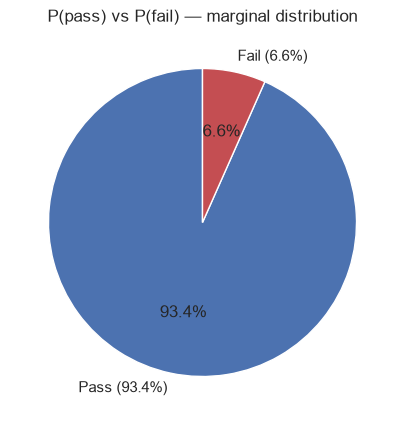

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [n_pass, n_fail],
    labels=[f'Pass ({p_pass:.1%})', f'Fail ({p_fail:.1%})'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#C44E52'],
)
ax.set_title('P(pass) vs P(fail) — marginal distribution')
plt.show()

### 1b. Conditional probability: P(fail | sensor above threshold)

**Concept.** Conditional probability P(A | B) = P(A and B) / P(B) — "given that B happened, what's the chance A also happened?" Here, B = "sensor reading is above some threshold" and A = "unit failed."

We split the data into two groups by a threshold on one sensor (e.g. its 75th percentile), then compute P(fail) *within each group* separately.

**What to observe:** compare P(fail | above), P(fail | at-or-below), and the overall P(fail) from 1a.
- If they're all roughly equal → the sensor and the outcome look independent (knowing the sensor value doesn't change your belief about failure).
- If they differ noticeably → the sensor and outcome look dependent, i.e. this sensor might carry information about failure risk.
This is descriptive, not a formal test — with only ~104 failures spread across 1567 rows, differences can arise from small-sample noise. A hypothesis test (e.g. chi-square test of independence) would be the rigorous version, which isn't covered in this notebook.

**Code walkthrough:**
- `secom[COND_FEATURE].quantile(THRESHOLD_QUANTILE)` computes the value below which `THRESHOLD_QUANTILE` (e.g. 0.75 → 75%) of the readings fall — this becomes the split point.
- `secom[secom[COND_FEATURE] > threshold]` is boolean-mask filtering: the inner comparison produces a `True`/`False` Series the same length as `secom`, and indexing with it keeps only the `True` rows.
- `(above[LABEL_COL] == 1).mean()` — `== 1` turns the label column into a `True`/`False` Series (`True` where it's a failure), and `.mean()` on a boolean Series is the fraction of `True` values, i.e. exactly the conditional probability estimate.

In [8]:
COND_FEATURE = '390'
THRESHOLD_QUANTILE = 0.75

threshold = secom[COND_FEATURE].quantile(THRESHOLD_QUANTILE)

above = secom[secom[COND_FEATURE] > threshold]
below_eq = secom[secom[COND_FEATURE] <= threshold]

p_fail_given_above = (above[LABEL_COL] == 1).mean()
p_fail_given_below_eq = (below_eq[LABEL_COL] == 1).mean()

print(f"Feature: {COND_FEATURE}, threshold (q={THRESHOLD_QUANTILE}) = {threshold:.4f}")
print(f"n above threshold    = {len(above)}")
print(f"n at/below threshold = {len(below_eq)}")
print()
print(f"P(fail)                        = {p_fail:.4f}")
print(f"P(fail | {COND_FEATURE} > thr)        = {p_fail_given_above:.4f}")
print(f"P(fail | {COND_FEATURE} <= thr)       = {p_fail_given_below_eq:.4f}")

Feature: 390, threshold (q=0.75) = 1.1482
n above threshold    = 392
n at/below threshold = 1175

P(fail)                        = 0.0664
P(fail | 390 > thr)        = 0.0587
P(fail | 390 <= thr)       = 0.0689


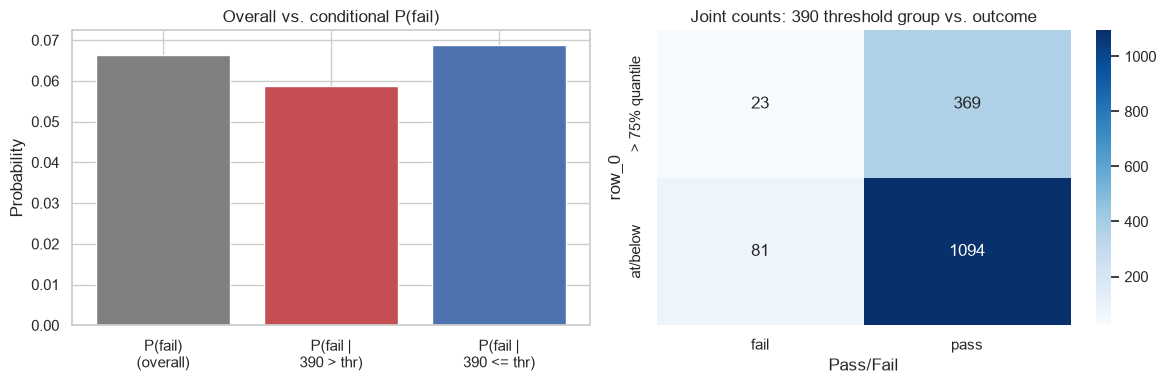

Pass/Fail,fail,pass
row_0,,
> 75% quantile,23,369
at/below,81,1094


In [9]:
# A Venn diagram is the natural picture for "overlap between two sets," but it isn't the clearest way to show
# a *conditional* comparison across three probabilities. A bar chart puts P(fail) side-by-side with the two
# conditional versions; a contingency-table heatmap shows the underlying joint counts (the same information a
# Venn diagram would encode, but exact and readable for a 2x2 split).

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['P(fail)\n(overall)', f'P(fail |\n{COND_FEATURE} > thr)', f'P(fail |\n{COND_FEATURE} <= thr)']
values = [p_fail, p_fail_given_above, p_fail_given_below_eq]
axes[0].bar(labels, values, color=['gray', '#C44E52', '#4C72B0'])
axes[0].set_ylabel('Probability')
axes[0].set_title('Overall vs. conditional P(fail)')

group = np.where(secom[COND_FEATURE] > threshold, f'> {THRESHOLD_QUANTILE:.0%} quantile', 'at/below')
contingency = pd.crosstab(group, secom[LABEL_COL].map({-1: 'pass', 1: 'fail'}))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Joint counts: {COND_FEATURE} threshold group vs. outcome')

plt.tight_layout()
plt.show()

contingency

## 2. Descriptive statistics

Six summary numbers per feature, each capturing a different aspect of the distribution's shape:

- **Mean** — the arithmetic average; sensitive to outliers/skew (a few huge values pull it a long way).
- **Median** — the middle value when sorted; robust to outliers. Comparing mean vs. median is itself a cheap skew check: if mean >> median, the distribution has a right tail dragging the average up (and vice versa).
- **Variance** — average of the squared deviations from the mean; the "amount of spread," in squared units of the original feature (hard to interpret directly because of the squaring).
- **Standard deviation** — square root of variance, back in the original units; the go-to spread measure.
- **Skewness** — asymmetry of the distribution. ~0 is symmetric, positive means a longer right tail, negative means a longer left tail.
- **Kurtosis** (excess, Fisher definition) — "tailedness" relative to a normal distribution. 0 = normal-like tails, positive = heavier tails / more extreme outliers than normal, negative = lighter/thinner tails.

**When to use this section:** as a first-pass numeric summary before plotting anything — it tells you which features are worth a closer look (e.g. very high |skew| or kurtosis) before you spend time on the distribution plots in Section 3.

**Code walkthrough:**
- `vals.var(ddof=1)` / `vals.std(ddof=1)` — `ddof` = "delta degrees of freedom." `ddof=1` divides by `n-1` instead of `n` (Bessel's correction), which gives an unbiased estimate of the *population* variance/std from a *sample*. This matters most for small `n`; with ~1500+ rows here the `n` vs `n-1` difference is tiny, but `n-1` is the statistically correct default for sample data (pandas' `.var()`/`.std()` already default to `ddof=1`, it's written explicitly here for clarity).
- `scipy.stats.skew` / `kurtosis` — used instead of a pandas built-in because they let you be explicit about the bias correction and definition (Fisher vs. Pearson) being used; `kurtosis(...)` here returns *excess* kurtosis (normal distribution = 0), which is the more common convention than "raw" kurtosis (normal = 3).

In [10]:
from scipy.stats import skew, kurtosis

desc_rows = []
for feat in SELECTED_FEATURES:
    vals = secom[feat].dropna()
    desc_rows.append({
        'feature': feat,
        'n': vals.count(),
        'mean': vals.mean(),
        'median': vals.median(),
        'variance': vals.var(ddof=1),
        'std_dev': vals.std(ddof=1),
        'skewness': skew(vals),
        'kurtosis_excess': kurtosis(vals),  # Fisher definition, normal = 0
    })

desc_table = pd.DataFrame(desc_rows).set_index('feature')
desc_table

,n,mean,median,variance,std_dev,skewness,kurtosis_excess
feature,,,,,,,
393,1567,0.133990,0.1339,0.001475,0.038408,0.102791,-0.513248
390,1567,1.431868,0.8773,413.163152,20.326415,39.524898,1560.809446
570,1567,530.523623,532.3982,306.240761,17.499736,-8.650636,86.577321
255,1567,0.403848,0.4051,0.014480,0.120334,0.210027,-0.365871
86,1567,2.401872,2.4039,0.001394,0.037332,-0.334234,1.081122


## 3. Distributions

### 3a. Histograms + KDE for each selected feature

**Histogram** — bins the feature's range into intervals and counts how many observations fall in each bin, drawn as bars. It's the most direct picture of "where do the values pile up." Bin count/width matters: too few bins hides structure, too many makes it noisy — `seaborn`/`matplotlib` pick a reasonable default automatically.

**KDE (Kernel Density Estimate)** — a smoothed, continuous curve estimating the underlying probability density, built by summing a small "bump" (kernel) centered at every data point. It's essentially a smoothed histogram that doesn't depend on bin edges, which makes shape comparisons (skew, modality) easier to read at a glance.

**When to use which:** histograms show you the actual data granularity (useful for spotting things like rounding artifacts or hard floors/ceilings); KDE is better for judging overall shape (is it unimodal? symmetric? long-tailed?). Plotting both together (`kde=True`) gives both views at once.

**What to observe:** number of humps (modality — one hump = unimodal, two = bimodal and possibly a mix of two underlying processes), symmetry vs. skew, and whether the shape looks bell-like at all — this is the visual counterpart to the skewness/kurtosis numbers from Section 2, and sets up the normality checks in 3b/3c.

**Code walkthrough:** `sns.histplot(secom[feat].dropna(), kde=True, ax=ax)` — `dropna()` removes any missing values before plotting (matplotlib/seaborn can't plot `NaN`s), and `kde=True` overlays the smoothed density curve on top of the histogram bars in the same call.

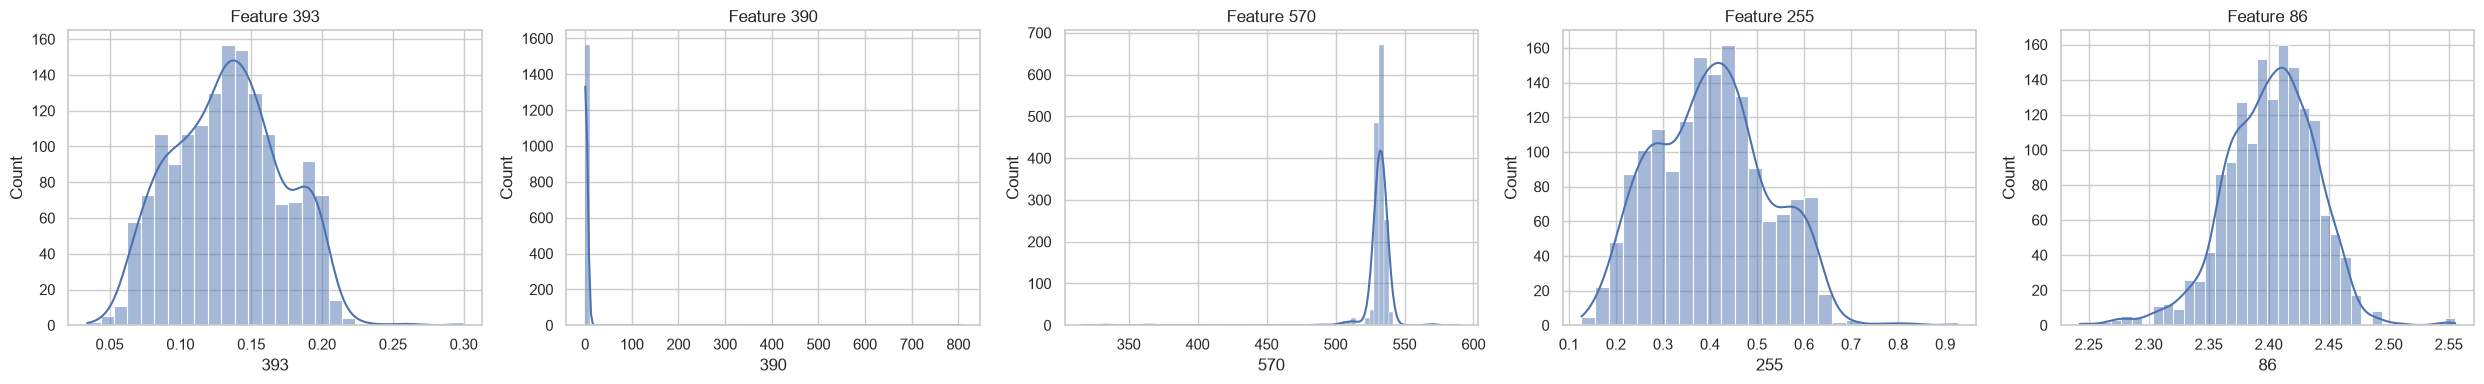

In [11]:
fig, axes = plt.subplots(1, len(SELECTED_FEATURES), figsize=(5 * len(SELECTED_FEATURES), 4))
for ax, feat in zip(axes, SELECTED_FEATURES):
    sns.histplot(secom[feat].dropna(), kde=True, ax=ax)
    ax.set_title(f'Feature {feat}')
plt.tight_layout()
plt.show()

### 3b. Q-Q plots (visual normality check)

**What it is.** A Q-Q (quantile-quantile) plot sorts your sample and plots each observed value against the value a perfect normal distribution *would* have at that same quantile/rank. If your data were exactly normal, every point would fall on the diagonal reference line.

**How to read it:**
- Points hugging the diagonal → consistent with normality.
- An S-shaped curve → skew (bending one way at the low end and the other way at the high end).
- Points curving away from the line at both ends → heavier tails than normal (more extreme values than a normal distribution would produce) — ties back to the kurtosis number from Section 2.

**When to use it over a histogram:** Q-Q plots are much more sensitive to departures from normality, especially in the tails, than eyeballing a histogram shape — small sample sizes can still look "bell-ish" in a histogram while showing a clear bend in a Q-Q plot.

**Code walkthrough:** `scipy.stats.probplot(vals, dist='norm', plot=ax)` computes the ordered sample quantiles and the matching theoretical quantiles from the distribution named in `dist` (here, `'norm'` = normal), fits a reference line, and draws both directly onto the given `ax`.

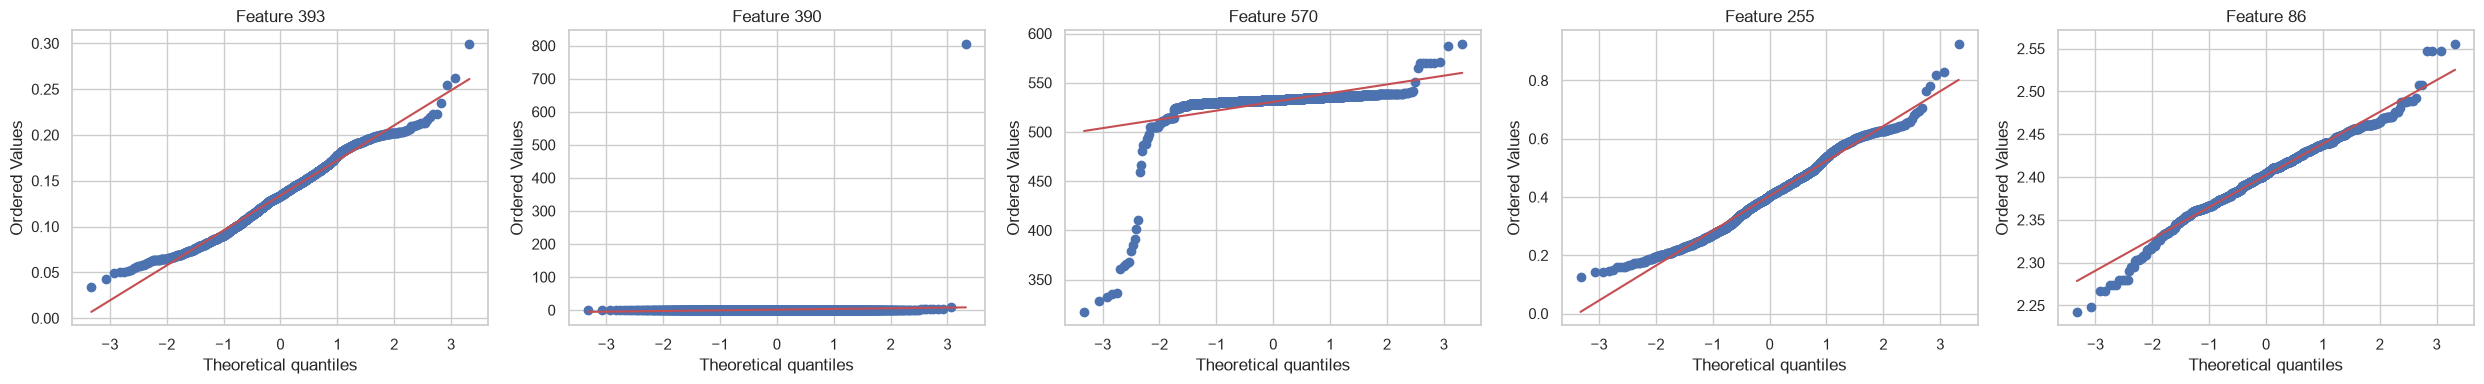

In [12]:
from scipy import stats as sps

fig, axes = plt.subplots(1, len(SELECTED_FEATURES), figsize=(5 * len(SELECTED_FEATURES), 4))
for ax, feat in zip(axes, SELECTED_FEATURES):
    sps.probplot(secom[feat].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Feature {feat}')
plt.tight_layout()
plt.show()

### 3c. Shapiro-Wilk normality test

**What it is.** A formal hypothesis test, not just a visual — it converts "does this look normal?" into a number you can threshold. It gives you a test statistic `W` (how well the data's shape matches a normal distribution — closer to 1 is more normal-like) and a `p-value`.

**Hypotheses:**
- H0 (null): the sample was drawn from a normal distribution.
- H1 (alternative): it was not.

**How to use the p-value:** pick a significance threshold (conventionally α = 0.05) *before* looking at the result. If p-value < α, reject H0 (evidence against normality); if p-value ≥ α, you fail to reject H0 (no evidence against normality — not the same as proving it's normal).

**Caveat worth knowing:** Shapiro-Wilk's power to detect non-normality grows with sample size. With ~1500 rows, even small, practically-irrelevant deviations from normality can produce a very small p-value — so treat this as one more piece of evidence alongside the histogram/Q-Q plot, not a single source of truth.

**Code walkthrough:** `scipy.stats.shapiro(vals)` returns a `(statistic, p_value)` tuple, unpacked directly into `stat, p_value`.

In [13]:
shapiro_rows = []
for feat in SELECTED_FEATURES:
    vals = secom[feat].dropna()
    stat, p_value = sps.shapiro(vals)
    shapiro_rows.append({'feature': feat, 'W_statistic': stat, 'p_value': p_value})

shapiro_table = pd.DataFrame(shapiro_rows).set_index('feature')
shapiro_table

,W_statistic,p_value
feature,,
393,0.987310,1.752237e-10
390,0.011343,5.258422e-67
570,0.259445,1.207464e-61
255,0.986943,1.101380e-10
86,0.985224,1.385752e-11


## 4. Sampling & the Central Limit Theorem

**Concept.** The Central Limit Theorem says: if you repeatedly draw random samples of size `n` from *any* distribution (normal or not) and compute the mean of each sample, the distribution of those *sample means* approaches a normal distribution as `n` grows — regardless of the shape of the original population. This is why so much of inferential statistics (including the confidence interval in Section 5) can lean on normal/t-distribution theory even when the raw data itself isn't normal.

**What we're doing:** picking one sensor (try both a skewed one and a near-symmetric one), repeatedly drawing random subsamples of size `SAMPLE_SIZE`, computing the mean of each subsample, and plotting the distribution of those means next to the original feature's distribution.

**What to observe:** the *original* distribution keeps whatever shape it has (skewed stays skewed), but the distribution of *sample means* should look progressively more bell-shaped and much narrower than the original, even when `CLT_FEATURE` is heavily skewed.

**Code walkthrough:**
- `np.random.default_rng(42)` creates a seeded random number generator — the seed (`42`) makes the "random" draws reproducible; rerunning the cell gives identical results.
- `rng.choice(population, size=SAMPLE_SIZE, replace=True)` draws `SAMPLE_SIZE` values at random from the full population array. `replace=True` means sampling *with* replacement — the same original data point can be picked more than once in a given subsample, which is the standard way to simulate "repeated random samples from the population" from a single finite dataset.
- `[... for _ in range(N_SAMPLES)]` is a list comprehension: repeat the draw-and-average step `N_SAMPLES` times, collecting one mean per iteration; `np.array(...)` wraps the resulting list of means for easy stats/plotting.

In [14]:
CLT_FEATURE = '390'  # try swapping for a skewed one vs. a near-normal one
SAMPLE_SIZE = 30
N_SAMPLES = 2000

population = secom[CLT_FEATURE].dropna().values
rng = np.random.default_rng(42)

sample_means = np.array([
    rng.choice(population, size=SAMPLE_SIZE, replace=True).mean()
    for _ in range(N_SAMPLES)
])

print(f"Population: n={len(population)}, mean={population.mean():.4f}, std={population.std(ddof=1):.4f}")
print(f"Sample means: n={len(sample_means)}, mean={sample_means.mean():.4f}, std={sample_means.std(ddof=1):.4f}")

Population: n=1567, mean=1.4319, std=20.3264
Sample means: n=2000, mean=1.3880, std=3.5174


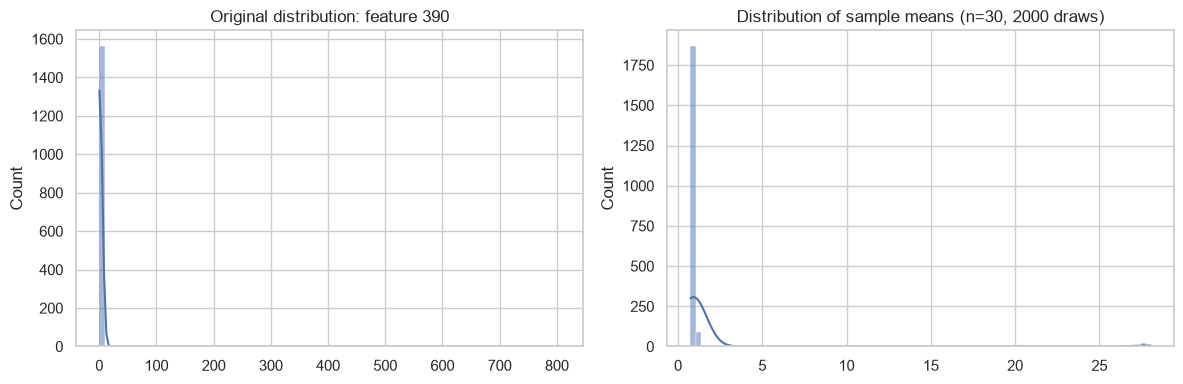

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(population, kde=True, ax=axes[0])
axes[0].set_title(f'Original distribution: feature {CLT_FEATURE}')

sns.histplot(sample_means, kde=True, ax=axes[1])
axes[1].set_title(f'Distribution of sample means (n={SAMPLE_SIZE}, {N_SAMPLES} draws)')

plt.tight_layout()
plt.show()

**Try it:** vary `SAMPLE_SIZE` (e.g. 5, 30, 100) and re-run the two cells above.

Two things to watch for as `SAMPLE_SIZE` increases:
1. **Shape** — the sample-means histogram should look more normal, faster, for less-skewed features; heavily skewed features (like `390`) typically need a larger `SAMPLE_SIZE` before the sample-means distribution looks convincingly bell-shaped (a common rule of thumb is n ≥ 30, but that's just a rule of thumb, not a hard rule).
2. **Spread** — the standard deviation of the sample means should shrink as `SAMPLE_SIZE` grows. This is the standard error relationship: SE = population std / sqrt(n) — larger samples give a more precise (less variable) estimate of the mean, which is exactly the quantity used in the confidence interval in Section 5.

## 5. Confidence intervals

**Concept.** A confidence interval gives a range of plausible values for the true population mean, built from a single sample. A 95% CI means: if you repeated this sampling-and-interval-construction process many times, about 95% of the resulting intervals would contain the true population mean. It is **not** "there's a 95% chance the true mean is in this specific interval" — the true mean is fixed, only the interval is random.

**Why the t-distribution instead of z (normal)?** The standard CI formula needs the *population* standard deviation, which we don't have — we only have the *sample* standard deviation as an estimate of it. Substituting an estimated std dev introduces extra uncertainty, which the t-distribution accounts for via wider tails than the normal distribution. The t-distribution converges to the normal distribution as sample size grows (degrees of freedom go up), so the correction matters most for small `n`.

**The formula, matching the steps below:**

CI = sample mean ± (t-critical × standard error), where standard error = sample std dev / sqrt(n)

**Code/step walkthrough:**
1. `sample_mean` — the point estimate of the population mean.
2. `sample_std = ci_vals.std(ddof=1)` — sample standard deviation using `n-1` (see Section 2 for why `ddof=1`).
3. `standard_error = sample_std / np.sqrt(n)` — how much the *sample mean* itself is expected to vary from sample to sample (this is the same quantity the CLT section demonstrated shrinking as `n` grows).
4. `df = n - 1`, `t_critical = sps.t.ppf(1 - alpha/2, df)` — `.ppf` (percent point function) is the inverse of the CDF: it answers "what t-value has this much probability to its left?" Using `1 - alpha/2` (rather than `1 - alpha`) accounts for a **two-tailed** interval — leaving `alpha/2` probability in each tail so the total excluded probability is `alpha` (e.g. 0.05 total → 0.025 per tail for a 95% CI).
5. `margin_of_error = t_critical * standard_error`, then `sample_mean ± margin_of_error` gives the final `(ci_lower, ci_upper)` interval.

**What to observe:** how the interval width changes if you swap `CI_FEATURE` for one with a much larger std dev, or if you go back and manually try a smaller `n` (e.g. `ci_vals.sample(30)`) — narrower samples produce wider, less precise intervals.

In [16]:
CI_FEATURE = '393'
CONFIDENCE_LEVEL = 0.95

ci_vals = secom[CI_FEATURE].dropna()
n = len(ci_vals)

# Step 1: sample mean
sample_mean = ci_vals.mean()

# Step 2: sample standard deviation (ddof=1 -> divides by n-1)
sample_std = ci_vals.std(ddof=1)

# Step 3: standard error of the mean
standard_error = sample_std / np.sqrt(n)

# Step 4: critical t-value for the given confidence level, df = n-1
alpha = 1 - CONFIDENCE_LEVEL
df = n - 1
t_critical = sps.t.ppf(1 - alpha / 2, df)

# Step 5: margin of error and final interval
margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Feature: {CI_FEATURE}")
print(f"n              = {n}")
print(f"sample mean    = {sample_mean:.4f}")
print(f"sample std     = {sample_std:.4f}")
print(f"standard error = {standard_error:.4f}")
print(f"df             = {df}")
print(f"t_critical     = {t_critical:.4f}")
print(f"margin of error= {margin_of_error:.4f}")
print(f"{int(CONFIDENCE_LEVEL*100)}% CI = ({ci_lower:.4f}, {ci_upper:.4f})")

Feature: 393
n              = 1567
sample mean    = 0.1340
sample std     = 0.0384
standard error = 0.0010
df             = 1566
t_critical     = 1.9615
margin of error= 0.0019
95% CI = (0.1321, 0.1359)


## 6. More EDA plot types for high-dimensional tabular data

The plots in Sections 1-5 covered `histplot`+`kdeplot`, `boxplot`, `heatmap`+`corr()`, `pairplot`, and grid layouts via `plt.subplots`. This section fills in the remaining common EDA plot types — comparing a feature across the pass/fail target, checking bivariate sensor relationships, class balance, and small multiples across many sensors at once.

### 6a. `sns.violinplot` — spread + shape across the pass/fail target

**Concept.** A boxplot (already used in week1) shows the five-number summary and flags outliers, but collapses the actual shape of the distribution down to a box. A violin plot mirrors a KDE on each side of the same axis, so **bimodality** is visible — e.g. if a sensor's failing units split into two distinct sub-populations rather than one shifted blob, a boxplot would hide that entirely while a violin plot shows it directly. Reach for it when comparing a continuous feature across a **small number of groups** — here, the binary `Pass/Fail` target.

**Signature (key params):** `sns.violinplot(data=df, x=..., y=..., inner='quartile')` — `inner` controls what's drawn inside each violin (`'quartile'` = quartile lines, `'box'` = a mini-boxplot, `'stick'` = raw points, `None` = nothing).

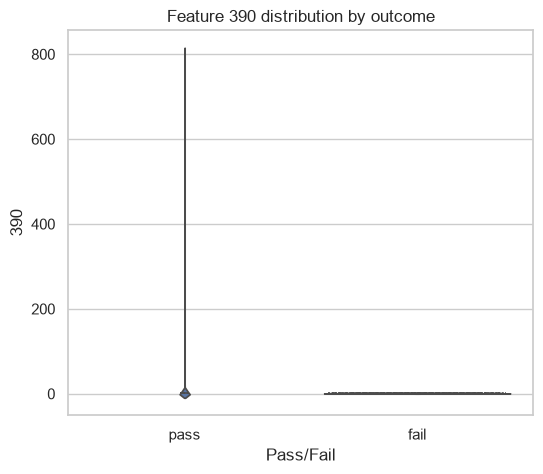

In [17]:
VIOLIN_FEATURE = '390'

plot_df = secom[[VIOLIN_FEATURE, LABEL_COL]].dropna().copy()
plot_df[LABEL_COL] = plot_df[LABEL_COL].map({-1: 'pass', 1: 'fail'})

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=plot_df, x=LABEL_COL, y=VIOLIN_FEATURE, inner='quartile', ax=ax)
ax.set_title(f'Feature {VIOLIN_FEATURE} distribution by outcome')
plt.show()

### 6b. `sns.scatterplot` / `sns.regplot` — bivariate sensor relationships

**Concept.** With 591 sensor columns, some are near-duplicates of each other (redundant instrumentation, derived readings) — spotting that visually before modeling avoids feeding a model collinear features unnecessarily. `sns.scatterplot` adds a `hue` mapping straight from a DataFrame column (e.g. color points by `Pass/Fail` to see if failures cluster in a particular region of two-sensor space), which plain `plt.scatter` can't do without manually looping/masking. `sns.regplot` overlays a fitted linear trend line with a confidence band, useful for judging whether two sensors move together roughly linearly.

**Signature (key params):** `sns.scatterplot(data=df, x=, y=, hue=, alpha=)` — `alpha` controls point transparency, essential once points start overlapping heavily. `sns.regplot(data=df, x=, y=, scatter_kws=, ci=95)` — `ci` sets the confidence band width around the trend line (`ci=None` skips it, faster on large data); `regplot` has no `hue` of its own — `sns.lmplot` is the hue-aware, figure-level version.

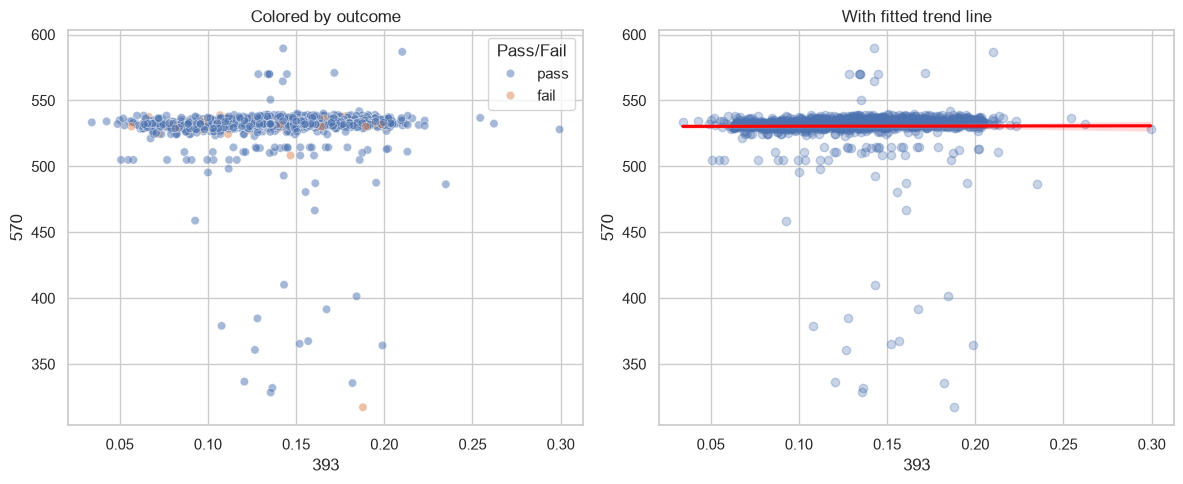

In [18]:
SCATTER_X, SCATTER_Y = '393', '570'

scatter_df = secom[[SCATTER_X, SCATTER_Y, LABEL_COL]].dropna().copy()
scatter_df[LABEL_COL] = scatter_df[LABEL_COL].map({-1: 'pass', 1: 'fail'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=scatter_df, x=SCATTER_X, y=SCATTER_Y, hue=LABEL_COL, alpha=0.5, ax=axes[0])
axes[0].set_title('Colored by outcome')

sns.regplot(data=scatter_df, x=SCATTER_X, y=SCATTER_Y, scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('With fitted trend line')

plt.tight_layout()
plt.show()

### 6c. `sns.countplot` / `sns.barplot` — class balance and grouped summary stats

**Concept.** Section 1 computed P(fail)/P(pass) numerically and plotted them as a pie chart. `sns.countplot` is the direct bar-chart version of a class-balance check: give it raw rows and a categorical column, it counts occurrences per category itself (no manual `.value_counts()` step first). `sns.barplot` is for a *summary statistic* per category rather than a count — e.g. the mean of a sensor within each pass/fail group — and it draws a confidence-interval error bar automatically.

**Signature (key params):** `sns.countplot(data=df, x=)` — just needs the categorical column, it aggregates internally. `sns.barplot(data=df, x=, y=, estimator='mean', errorbar='ci')` — `estimator` is the aggregation function per group (swap for `'median'`, etc.); `errorbar=None` drops the confidence-interval whiskers if not needed.

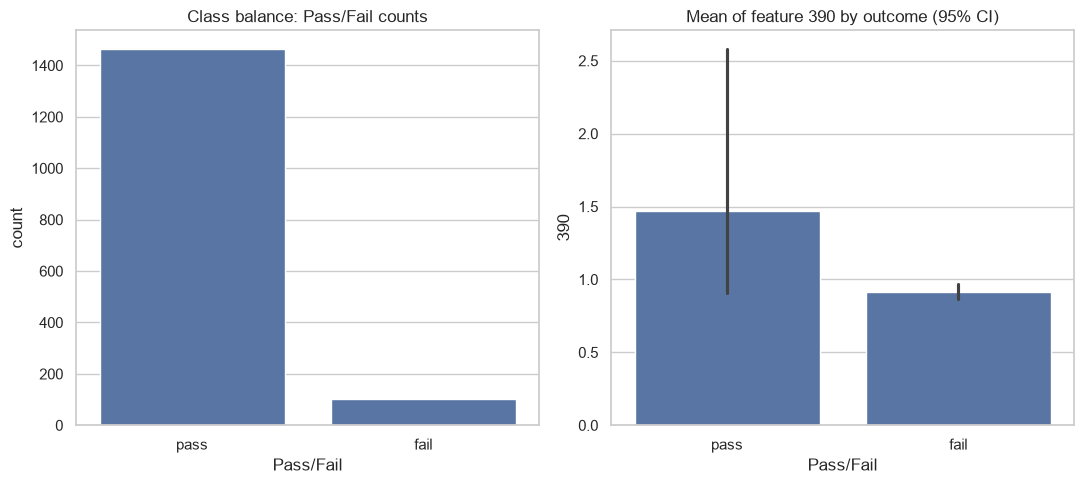

In [19]:
BAR_FEATURE = '390'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.countplot(data=plot_df, x=LABEL_COL, ax=axes[0])
axes[0].set_title('Class balance: Pass/Fail counts')

bar_df = secom[[BAR_FEATURE, LABEL_COL]].dropna().copy()
bar_df[LABEL_COL] = bar_df[LABEL_COL].map({-1: 'pass', 1: 'fail'})
sns.barplot(data=bar_df, x=LABEL_COL, y=BAR_FEATURE, estimator='mean', errorbar='ci', ax=axes[1])
axes[1].set_title(f'Mean of feature {BAR_FEATURE} by outcome (95% CI)')

plt.tight_layout()
plt.show()

### 6d. `sns.catplot` / `sns.FacetGrid` — small multiples across many sensors

**Concept.** With hundreds of sensor columns, looking at one plot per feature one cell at a time doesn't scale. Faceting draws a grid of subplots, one per category, from a single call. `sns.catplot` is the figure-level wrapper around categorical plot kinds (`kind='box'`, `'violin'`, `'bar'`, ...); `sns.FacetGrid` is the lower-level version you `.map()` any plotting function onto. Both need the data reshaped so the thing you're faceting by (sensor name) is itself a column — done here with `pd.melt`, turning the wide `SELECTED_FEATURES` columns into a single `sensor`/`value` pair of columns.

**Signature (key params):** `sns.catplot(data=, x=, y=, col=, col_wrap=, kind=, sharey=)` — `col` picks the faceting column, `col_wrap` wraps the grid after N columns instead of one long row, `sharey=False` lets each facet use its own y-axis scale (important here since raw sensor ranges differ by orders of magnitude — this is the `sharex`/`sharey` behavior `plt.subplots` grids elsewhere in this notebook haven't needed to set explicitly).

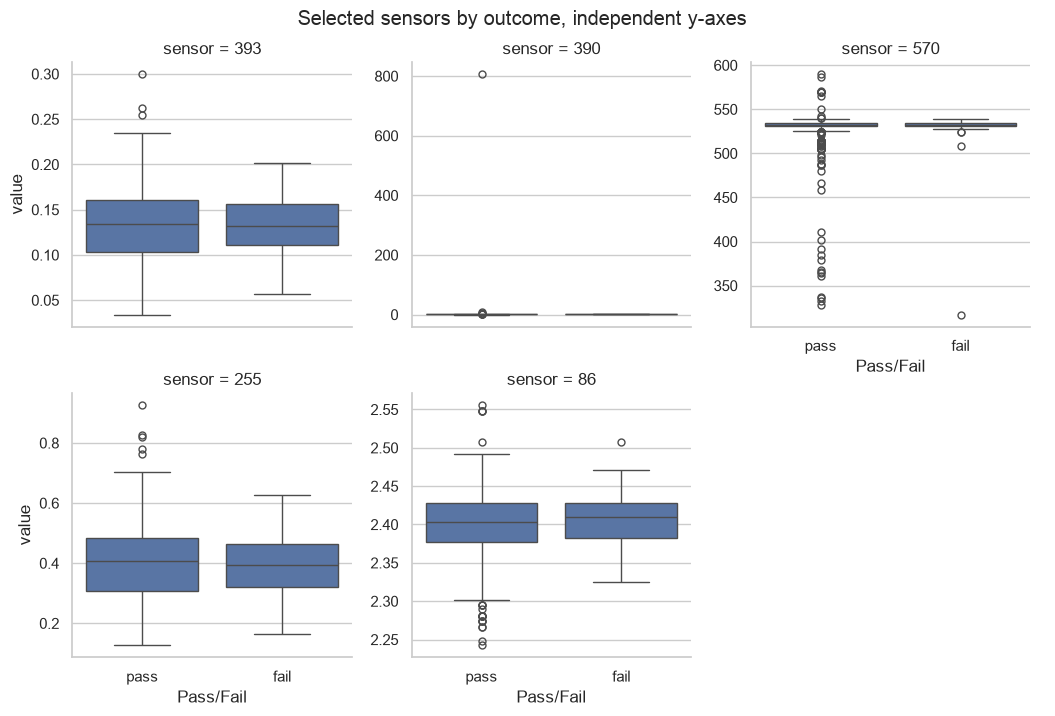

In [20]:
facet_long = secom[SELECTED_FEATURES + [LABEL_COL]].dropna().melt(
    id_vars=LABEL_COL, var_name='sensor', value_name='value'
)
facet_long[LABEL_COL] = facet_long[LABEL_COL].map({-1: 'pass', 1: 'fail'})

g = sns.catplot(
    data=facet_long, x=LABEL_COL, y='value', col='sensor',
    col_wrap=3, kind='box', sharey=False, height=3.5,
)
g.figure.suptitle('Selected sensors by outcome, independent y-axes', y=1.02)
plt.show()